In [1]:
#source activate newEnv
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
library(tibble)
library(broom)
library("parallel")
library(tidyr)
library(stringr)
library(qvalue)

Warning message:
“package ‘qvalue’ was built under R version 4.4.2”


In [2]:
cells <- scan('/nfs/lab/tscc/rlmelton/liver_HOMER/liver_data/listofcells.txt', what="", sep="\n")
cells <- cells[cells != 'Bulk']
cells

[1] "B"             "Cholangiocyte" "Endothelial"   "Hepatocytes"  
 [5] "HSC"           "Mast"          "Myeloid"       "NK"           
 [9] "Schwann"       "T"

# Save GRN beds

In [3]:
grns <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/SCENIC/Hepatocytes/eRegulon_direct.tsv', header=T)

dim(grns)
head(grns)

[1] 35155    15

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>
1,chr4:73965001-73965301,CXCL2,0.02447437,0.12776317,0.003126923,0.003126923,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),1.7770506,1,0.19948248,15869
2,chr3:189383753-189384053,TPRG1,0.01759522,0.10194220,0.001793696,0.001793696,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),3.2928309,1,0.38799972,3467
3,chr16:30844748-30845048,ORAI3,0.10015906,0.05560605,0.005569450,0.005569450,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),1.2935095,1,0.07809416,11437
4,chr8:26693755-26694055,ADRA1A,0.02128050,0.25861542,0.005503467,0.005503467,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),3.0368573,1,0.38357860,2867
5,chr4:68963470-68963770,UGT2B7,0.09891115,0.16103632,0.015928288,0.015928288,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),2.5326155,1,0.18274981,1052
6,chrX:53086539-53086808,KANTR,0.19290936,0.08702135,0.016787234,0.016787234,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),0.7767084,1,0.19450613,222


In [4]:
length(unique(grns$Region))

[1] 19388

In [5]:
GRN.c1=c('CREB5_direct_+/+',
'FLI1_direct_+/+',
'ETS1_direct_+/+',
'E2F3_direct_+/+',
'RUNX1_direct_+/+',
'RB1_direct_+/+',
'HMGXB3_direct_+/+',
'ERG_direct_+/+',
'ZNF654_direct_+/+',
'ZBTB7A_direct_+/+',
'NFATC2_direct_+/+',
'MBD2_direct_+/+',
'ELF3_direct_+/+',
'IKZF1_direct_+/+',
'ETV5_direct_+/+',
'ELK4_direct_+/+',
'CUX1_direct_+/+',
'PHF20_direct_+/+',
'RXRA_direct_+/+',
'ZBTB21_direct_+/+',
'RELB_direct_+/+',
'PPARD_direct_+/+',
'GATAD2A_direct_+/+',
'KLF6_direct_+/+',
'TEAD1_direct_+/+',
'ETS2_direct_+/+',
'SPI1_direct_+/+',
'ATF3_direct_+/+',
'FOXK2_direct_+/+',
'FOSL2_direct_+/+')
GRN.c2=c('FOXA1_direct_+/+',
'ATF5_direct_+/+',
'REL_direct_+/+',
'NFKB1_direct_+/+',
'FOXK1_direct_+/+',
'CREB1_direct_+/+',
'SREBF2_direct_+/+',
'NFAT5_direct_+/+',
'ZNF644_direct_+/+',
'CHD2_direct_+/+',
'TBL1XR1_direct_+/+',
'GABPB1_direct_+/+',
'ELF1_direct_+/+')
GRN.c3=c('HNF4G_direct_+/+',
'PPARG_direct_+/+',
'ZEB1_direct_+/+',
'TCF7L2_direct_+/+',
'STAT1_direct_+/+')
GRN.c4=c('KLF13_direct_+/+',
'NFIC_direct_+/+',
'PPARA_direct_+/+',
'KLF3_direct_+/+',
'HNF4A_direct_+/+',
'NR1I2_direct_+/+',
'CUX2_direct_+/+',
'ZBTB20_direct_+/+',
'KLF9_direct_+/+',
'RORA_direct_+/+',
'ZNF326_direct_+/+',
'NR3C2_direct_+/+',
'TFDP2_direct_+/+',
'EP300_direct_+/+',
'NFYC_direct_+/+',
'AR_direct_+/+',
'KLF12_direct_+/+',
'TRPS1_direct_+/+',
'NFIA_direct_+/+',
'PBX3_direct_+/+')
GRN.c5=c('MLXIPL_direct_+/+',
'FOXO1_direct_+/+',
'FOXP1_direct_+/+',
'EGR1_direct_+/+',
'NR4A1_direct_+/+',
'FOS_direct_+/+',
'ATF6_direct_+/+')
GRN.c6=c('ONECUT1_direct_+/+',
'STAT2_direct_+/+',
'FOXP2_direct_+/+',
'ETV1_direct_+/+',
'SP3_direct_+/+',
'GATA4_direct_+/+',
'NR1H4_direct_+/+',
'THRB_direct_+/+',
'RBFOX2_direct_+/+',
'HIVEP1_direct_+/+',
'CEBPD_direct_+/+',
'NR3C1_direct_+/+',
'STAT3_direct_+/+',
'FOXJ3_direct_+/+',
'CHD1_direct_+/+',
'ETV6_direct_+/+',
'BACH2_direct_+/+',
'NFE2L2_direct_+/+',
'CREM_direct_+/+')

In [7]:
length(GRN.c1)
sum(GRN.c1 %in% grns$eRegulon_name)

length(GRN.c2)
sum(GRN.c2 %in% grns$eRegulon_name)

length(GRN.c3)
sum(GRN.c3 %in% grns$eRegulon_name)

length(GRN.c4)
sum(GRN.c4 %in% grns$eRegulon_name)

length(GRN.c5)
sum(GRN.c5 %in% grns$eRegulon_name)

length(GRN.c6)
sum(GRN.c6 %in% grns$eRegulon_name)

[1] 30

[1] 30

[1] 13

[1] 13

[1] 5

...

[1] 20

[1] 7

[1] 7

[1] 19

[1] 19

In [19]:
clusters

[1] "CREB5_direct_+/+"   "FLI1_direct_+/+"    "ETS1_direct_+/+"   
 [4] "E2F3_direct_+/+"    "RUNX1_direct_+/+"   "RB1_direct_+/+"    
 [7] "HMGXB3_direct_+/+"  "ERG_direct_+/+"     "ZNF654_direct_+/+" 
[10] "ZBTB7A_direct_+/+"  "NFATC2_direct_+/+"  "MBD2_direct_+/+"   
[13] "ELF3_direct_+/+"    "IKZF1_direct_+/+"   "ETV5_direct_+/+"   
[16] "ELK4_direct_+/+"    "CUX1_direct_+/+"    "PHF20_direct_+/+"  
[19] "RXRA_direct_+/+"    "ZBTB21_direct_+/+"  "RELB_direct_+/+"   
[22] "PPARD_direct_+/+"   "GATAD2A_direct_+/+" "KLF6_direct_+/+"   
[25] "TEAD1_direct_+/+"   "ETS2_direct_+/+"    "SPI1_direct_+/+"   
[28] "ATF3_direct_+/+"    "FOXK2_direct_+/+"   "FOSL2_direct_+/+"  
[31] "FOXA1_direct_+/+"   "ATF5_direct_+/+"    "REL_direct_+/+"    
[34] "NFKB1_direct_+/+"   "FOXK1_direct_+/+"   "CREB1_direct_+/+"  
[37] "SREBF2_direct_+/+"  "NFAT5_direct_+/+"   "ZNF644_direct_+/+" 
[40] "CHD2_direct_+/+"    "TBL1XR1_direct_+/+" "GABPB1_direct_+/+" 
[43] "ELF1_direct_+/+"    "HNF4G_direct_+/+"   "PPARG_direct_+/+"  
[46] "ZEB1_direct_+/+"    "TCF7L2_direct_+/+"  "STAT1_direct_+/+"  
[49] "KLF13_direct_+/+"   "NFIC_direct_+/+"    "PPARA_direct_+/+"  
[52] "KLF3_direct_+/+"    "HNF4A_direct_+/+"   "NR1I2_direct_+/+"  
[55] "CUX2_direct_+/+"    "ZBTB20_direct_+/+"  "KLF9_direct_+/+"   
[58] "RORA_direct_+/+"    "ZNF326_direct_+/+"  "NR3C2_direct_+/+"  
[61] "TFDP2_direct_+/+"   "EP300_direct_+/+"   "NFYC_direct_+/+"   
[64] "AR_direct_+/+"      "KLF12_direct_+/+"   "TRPS1_direct_+/+"  
[67] "NFIA_direct_+/+"    "PBX3_direct_+/+"    "MLXIPL_direct_+/+" 
[70] "FOXO1_direct_+/+"   "FOXP1_direct_+/+"   "EGR1_direct_+/+"   
[73] "NR4A1_direct_+/+"   "FOS_direct_+/+"     "ATF6_direct_+/+"   
[76] "ONECUT1_direct_+/+" "STAT2_direct_+/+"   "FOXP2_direct_+/+"  
[79] "ETV1_direct_+/+"    "SP3_direct_+/+"     "GATA4_direct_+/+"  
[82] "NR1H4_direct_+/+"   "THRB_direct_+/+"    "RBFOX2_direct_+/+" 
[85] "HIVEP1_direct_+/+"  "CEBPD_direct_+/+"   "NR3C1_direct_+/+"  
[88] "STAT3_direct_+/+"   "FOXJ3_direct_+/+"   "CHD1_direct_+/+"   
[91] "ETV6_direct_+/+"    "BACH2_direct_+/+"   "NFE2L2_direct_+/+" 
[94] "CREM_direct_+/+"

In [20]:
clusters <- list(GRN.c1,GRN.c2,GRN.c3,GRN.c4,GRN.c5,GRN.c6)
for (i in 1:length(clusters)) {
    clust <- clusters[[i]]
    grns %>%
        filter( eRegulon_name %in% clust) %>%
        select(Region) %>%
        unlist() %>%
        str_split(':|-', simplify=T) %>%
        write.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc',i,'_Features.bed'),
                   sep='\t', col.names=F, row.names=F, quote=F)
}

In [21]:
clust

[1] "ONECUT1_direct_+/+" "STAT2_direct_+/+"   "FOXP2_direct_+/+"  
 [4] "ETV1_direct_+/+"    "SP3_direct_+/+"     "GATA4_direct_+/+"  
 [7] "NR1H4_direct_+/+"   "THRB_direct_+/+"    "RBFOX2_direct_+/+" 
[10] "HIVEP1_direct_+/+"  "CEBPD_direct_+/+"   "NR3C1_direct_+/+"  
[13] "STAT3_direct_+/+"   "FOXJ3_direct_+/+"   "CHD1_direct_+/+"   
[16] "ETV6_direct_+/+"    "BACH2_direct_+/+"   "NFE2L2_direct_+/+" 
[19] "CREM_direct_+/+"

In [22]:
grns %>%
    select(Region) %>%
    unlist() %>%
    str_split(':|-', simplify=T) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed',
               sep='\t', col.names=F, row.names=F, quote=F)

# Write FINRICH commands

In [10]:
grn <- 1:6

trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/', full.names = TRUE)
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/'

celltypes <- c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')

In [11]:
#dir.create('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [12]:
setwd('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [13]:
head(trait_beds)

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed"
[2] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.EUR.MVP.2021.credset.bed"  
[3] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_WIDE_Hg38.bed"       
[4] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_Hg38.bed"            
[5] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_Hg38.bed"            
[6] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_EARLY_Hg38.bed"

In [18]:
length(clusters)

[1] 94

In [14]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/'

In [25]:
Sys.time()
commands <- character()

# Run for DE sites
for(FILE in trait_beds[1]){
    CELL <- 'Hepatocytes'
    cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed',
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)
    
    # Run for GRNs
    
    bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed'
    
    for (i in 1:length(clusters)) {
        input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc',i,'_Features.bed')
        commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    }
    
    
}

Sys.time()

length(commands)
head(commands)
tail(commands)

commands[str_detect(commands, 'nfs')]

[1] "2025-02-20 21:49:15 PST"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed



[1] "2025-02-20 21:49:15 PST"

[1] 6

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc1_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc1_Features.bed.results "
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc2_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc2_Features.bed.results "
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc3_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc3_Features.bed.results "
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc4_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc4_Features.bed.results "
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc5_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc5_Features.bed.results "
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc6_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc6_Features.bed.results "

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc1_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc1_Features.bed.results "
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc2_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc2_Features.bed.results "
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc3_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc3_Features.bed.results "
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc4_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc4_Features.bed.results "
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc5_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc5_Features.bed.results "
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/250220_WE_GRNc6_Features.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/250220_WE_GRN_Features.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc6_Features.bed.results "

character(0)

In [26]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/250220_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

# Results

In [30]:
out.dir.ophelia <- paste0(str_replace(out.dir, '/tscc/projects/ps-gaultonlab', '/nfs/lab/tscc'))
out.dir.ophelia

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/"

In [31]:
files <- list.files(out.dir.ophelia)

length(files)
head(files)
tail(files)

[1] 85

[1] "241218_5k_ATAC_markers_FINRICH_results.tsv"
[2] "241218_5k_ATAC_markers_FINRICH.tsv"        
[3] "241218_5k_DESeq_FINRICH.tsv"               
[4] "241218_cluster_all_sites_FINRICH.tsv"      
[5] "241218_cluster_FINRICH.tsv"                
[6] "241218_DESeq_ATAC_FINRICH_results.tsv"

[1] "Myeloid__241217_WE_Myeloid_disease_MASH_clusters.bed"   
[2] "Myeloid__241217_WE_Myeloid_disease_MASH_on_clusters.bed"
[3] "Myeloid__241217_WE_Myeloid_disease_MASL_clusters.bed"   
[4] "Myeloid__241217_WE_Myeloid_disease_MASL_on_clusters.bed"
[5] "Myeloid__241217_WE_Myeloid_disease_MetALD_clusters.bed" 
[6] "old"

### Clusters

In [32]:
files[str_detect(files, '250220')]

[1] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc1_Features.bed.results"
[2] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc2_Features.bed.results"
[3] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc3_Features.bed.results"
[4] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc4_Features.bed.results"
[5] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc5_Features.bed.results"
[6] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc6_Features.bed.results"

In [34]:
out.df <- data.frame()

for (i in 1:6) {
    file <- paste0('Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__250220_WE_GRNc',i,'_Features.bed.results')
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(file, '__', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    test.group <- 'GRNs'
    
    unit <- paste0('GRNc',i)
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- NA
        results$modality <- 'ATAC'
        results$DESeq_direction <- NA
        results$Sig_level <- NA
        results$cell_type <- ct
        results$unit <- unit
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

#Endo differential - no loci in background

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,NA,ATAC,NA,NA,Hepatocytes,GRNc1,0.062,2.731532501878583,1.4317260581778686,-0.4423253504135809,4.715196819506465
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,NA,ATAC,NA,NA,Hepatocytes,GRNc2,0.686,0.09230934708394772,-2.442966768943899,-4.567302671416675,6.636249510172376
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,NA,ATAC,NA,NA,Hepatocytes,GRNc3,0.213,1.3539138325598934,0.31817771542747164,-1.8820261519140928,13.811358399792196
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,NA,ATAC,NA,NA,Hepatocytes,GRNc4,0.038,3.46210799462201,1.5417251695137968,-0.4427753749381331,7.283459652513322
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,NA,ATAC,NA,NA,Hepatocytes,GRNc5,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,NA,ATAC,NA,NA,Hepatocytes,GRNc6,0.805,0.08980546643225755,-2.513548852861809,-4.481922450436898,2.6503525121207234


In [35]:
select(out.df, trait, ct, test.group, unit, pval, fold_enrich, logOR, conf_lower, conf_upper)

trait,ct,test.group,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,GRNc1,0.062,2.731532501878583,1.4317260581778686,-0.4423253504135809,4.715196819506465
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,GRNc2,0.686,0.09230934708394772,-2.442966768943899,-4.567302671416675,6.636249510172376
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,GRNc3,0.213,1.3539138325598934,0.31817771542747164,-1.8820261519140928,13.811358399792196
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,GRNc4,0.038,3.46210799462201,1.5417251695137968,-0.4427753749381331,7.283459652513322
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,GRNc5,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,GRNs,GRNc6,0.805,0.08980546643225755,-2.513548852861809,-4.481922450436898,2.6503525121207234


In [37]:
p.adjust(out.df$pval, method='fdr')

[1] 0.186 0.966 0.426 0.186 1.000 0.966

In [36]:
select(out.df, trait, ct, test.group, unit, pval, fold_enrich, logOR, conf_lower, conf_upper) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/250220_cluster_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
cluster.df <- out.df

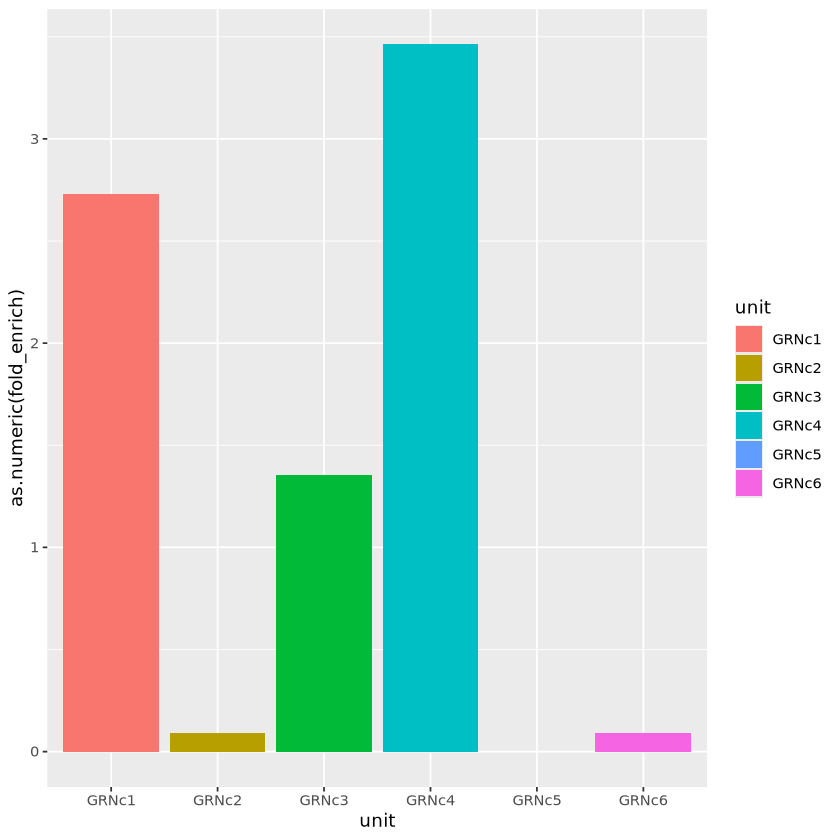

In [42]:
ggplot(out.df, aes(x=unit, y=as.numeric(fold_enrich), fill=unit)) + geom_col()